In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]
llm = ChatGroq(model=os.getenv("QWEN_MODEL"))

# **Custom logic to Build Human in The Loop**

In [2]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [3]:
@tool
def multiply(a: int, b: int) -> int:
    """This is multiply function"""
    
    return a * b

In [4]:
@tool
def search(query: str):
    "Search the wrb for a query and return the results"
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    
    return f"Result for {query} is: \n{result}"

response = search.invoke(
    {
        "query": "What is the capital of bangladesh?"
    }
)
response

'Result for What is the capital of bangladesh? is: \n[{\'title\': "Bangladesh\'s capital is Dhaka - Geography - Mammoth Memory", \'url\': \'https://mammothmemory.net/geography/world/asia/what-are-the-asian-capital-cities/i/bangladesh.html\', \'content\': "Mammoth Memory\\n\\n# Bangladesh – Bangladesh\'s capital is Dhaka\\n\\n### (Pronounced bahng-gluh-desh and dak-uh)\\n\\nTo remember the capital of Bangladesh, use the following mnemonic:\\n\\nBang the dish (Bangladesh) and the lights go out. It gets darker (Dhaka).\\n\\nang the dish (Bangladesh) and the lights go out. It gets darker (Dhaka).\\n\\nang the dish (Bangladesh) and the lights go out. It gets darker (Dhaka).\\n\\nBack to list", \'score\': 0.90692574}, {\'title\': \'Dhaka Travel Guide: Explore the Capital City of Bangladesh\', \'url\': \'https://koryogroup.com/travel-guide/dhaka-bangladesh-capital-city\', \'content\': \'# Dhaka, Bangladesh | Bangladesh Travel Guide\\n\\nBy Zoe Stephens\\n\\nDhaka, the bustling capital of Bang

In [5]:
tools = [multiply, search]
tools

[StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000020BD8CCC7C0>),
 StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000020BD64C9C60>)]

In [6]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

## **To see How tools call work in the React Workflow**

In [7]:
tool_mapping = {tool.name: tool for tool in tools}
tool_mapping

{'multiply': StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000020BD8CCC7C0>),
 'search': StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000020BD64C9C60>)}

In [8]:
tool_mapping["search"]

StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000020BD64C9C60>)

In [9]:
tool_mapping["search"].invoke(
    {
        "query": "who is dr. yunus?"
    }
)

'Result for who is dr. yunus? is: \n[{\'title\': \'Muhammad Yunus (Bangladesh) | unfoundation.org\', \'url\': \'https://unfoundation.org/who-we-are/our-people/muhammad-yunus-bangladesh/\', \'content\': \'In 1974, Dr. Yunus pioneered the idea of Gram Sarker (village government) as a form of local government based on the participation of rural people. This concept proved successful and was adopted by the Bangladeshi government in 1980. In 1978, Yunus received the President’s Award for Tebhaga Khamar (a system of cooperative three-share farming, which the Bangladeshi government adopted as the Packaged Input Program in 1977). Dr. Yunus is also noted for the creation of “micro-credit,” which [...] Dr. Yunus has received widespread recognition for his work, including the Nobel Peace Prize, the Ramon Magsaysay Award from Manila, the Aga Khan Award for Architecture from Geneva, the Mohamed Shabdeen Award for Science from Sri Lanka and the World Food Prize from the United States. Within Banglad

In [10]:
response = llm_with_tools.invoke("what is the current weather in bangladesh.")

## **Llm route to tools call**

In [11]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current weather in Bangladesh. Let me check the available tools. There\'s a search function that takes a query string. Since there\'s no specific weather function, I can use the search tool to look up the current weather. I\'ll need to form a query string like "current weather in Bangladesh" and call the search function with that. That should retrieve the necessary information.\n', 'tool_calls': [{'id': '8pxf3k1rr', 'function': {'arguments': '{"query":"current weather in Bangladesh"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 199, 'total_tokens': 307, 'completion_time': 0.177689117, 'prompt_time': 0.007524254, 'queue_time': 0.051040056, 'total_time': 0.185213371}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a300d22d-9ac9-413e-8cd

In [19]:
response.tool_calls[0]

{'name': 'search',
 'args': {'query': 'current weather in Bangladesh'},
 'id': '8pxf3k1rr',
 'type': 'tool_call'}

In [12]:
tool_mapping[response.tool_calls[0]["name"]].invoke(response.tool_calls[0]["args"])

'Result for current weather in Bangladesh is: \n[{\'title\': \'Weather in Bangladesh in July 2025 - Detailed Forecast\', \'url\': \'https://www.easeweather.com/asia/bangladesh/july\', \'content\': \'| 11 Jul. | Patchy rain possible Patchy rain possible | 33° /26° | 0.5 mm | 2.5 |  |\\n| 12 Jul. | Patchy rain possible Patchy rain possible | 34° /26° | 0.8 mm | 2.4 |  |\\n| 13 Jul. | Patchy rain possible Patchy rain possible | 34° /27° | 1.2 mm | 1.9 |  |\\n| 14 Jul. | Patchy rain possible Patchy rain possible | 32° /27° | 4.8 mm | 2.2 |  |\\n| 15 Jul. | Patchy rain possible Patchy rain possible | 33° /26° | 1.4 mm | 6 |  | [...] | 6 Jul. | Light rain shower Light rain shower | 32° /25° | 8.2 mm | 7 |  |\\n| 7 Jul. | Light rain shower Light rain shower | 31° /26° | 8.8 mm | 7 |  |\\n| 8 Jul. | Moderate or heavy rain shower Moderate or heavy rain shower | 31° /26° | 7.2 mm | 7 |  |\\n| 9 Jul. | Moderate or heavy rain shower Moderate or heavy rain shower | 32° /26° | 14.7 mm | 7 |  |\\n| 1

## **Now Build the Graph**

In [13]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

In [14]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [31]:
def invoke_model(state:AgentState):
    question = state['messages'][-1]
    
    print(question)
    response = llm_with_tools.invoke(question)
    
    return {
        "messages": [response]
    }

In [32]:
def router(state: AgentState):
    print("--enter into router--")
    tool_calls = state["messages"][-1].tool_calls
    print(tool_calls)
    
    if len(tool_calls) > 0:
        return "tool_call"
    else:
        return "end"
    

In [61]:
def invoke_tool(state:AgentState):
    print("--start tool call--")
    tool_details = state["messages"][-1].tool_calls
    print(tool_details)
    
    if tool_details is None:
        return Exception("No tool calls found in the last messages.")
    print("Selected tool: {tool_details[0]['name']}")
    
    print("i'm hare-1")
    
    if tool_details[0]["name"] == "search":
        user_input = input("Say 'yes' to call the tool otherwise say 'no'.")
        
        if user_input.lower() == 'no':
            print("Web search discarded by user")
            raise Exception(ValueError)
        
    response = tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {
        "messages": [response]
    }

- eariler we were using the tool node from list of tool

- but now we have crate tool invoke(custom funtion)

- why we are doing it: as a user if we want to take a authority to which i need to give permission for execution

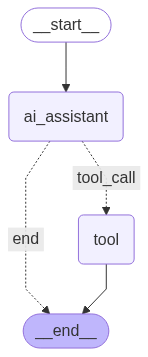

In [62]:
from langgraph.graph import StateGraph, START,END
graph=StateGraph(AgentState)

graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool_call":"tool",
                                "end":END
                            }
                            )
graph.add_edge("tool", END)

graph.set_entry_point("ai_assistant")
app = graph.compile()
app

In [63]:
app.invoke(
    {
        "messages": ["Hello how are you?"]
    }
)

Hello how are you?
--enter into router--
[]


{'messages': ['Hello how are you?',
  AIMessage(content='Hello! How can I assist you?', additional_kwargs={'reasoning_content': 'Okay, the user asked "Hello how are you?" So, I need to respond appropriately. Let me check the tools available. There\'s a multiply function and a search function. But the user isn\'t asking for a calculation or a search. They\'re just greeting me. Since there\'s no function needed here, I should just reply with a friendly greeting. Let me make sure I don\'t call any functions unnecessarily. Alright, I\'ll respond with a simple "Hello! How can I assist you?" without using any tools.\n'}, response_metadata={'token_usage': {'completion_tokens': 119, 'prompt_tokens': 195, 'total_tokens': 314, 'completion_time': 0.216769003, 'prompt_time': 0.007378316, 'queue_time': 0.055927894, 'total_time': 0.224147319}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_8487b76fd3', 'finish_reason': 'stop', 'logprobs': None}, id='run--40a87e40-6172-4e29-baae-bdaaba2d5c

In [65]:
output = app.invoke(
    {
        "messages": ["What is the current GDP of the Bangladesh?"]
    }
)

What is the current GDP of the Bangladesh?
--enter into router--
[{'name': 'search', 'args': {'query': 'current GDP of Bangladesh'}, 'id': '16e3061z2', 'type': 'tool_call'}]
--start tool call--
[{'name': 'search', 'args': {'query': 'current GDP of Bangladesh'}, 'id': '16e3061z2', 'type': 'tool_call'}]
Selected tool: {tool_details[0]['name']}
i'm hare-1


In [66]:
print(output["messages"][-1])

Result for current GDP of Bangladesh is: 
[{'title': 'Bangladesh GDP - Trading Economics', 'url': 'https://tradingeconomics.com/bangladesh/gdp', 'content': '##### Members\n\n##### \n\n# Bangladesh GDP\n\n## The Gross Domestic Product (GDP) in Bangladesh was worth 450.12 billion US dollars in 2024, according to official data from the World Bank. The GDP value of Bangladesh represents 0.42 percent of the world economy. source: World Bank [...] | Related | Last | Previous | Unit | Reference |\n| --- | --- | --- | --- | --- |\n| GDP | 450.12 | 437.42 | USD Billion | Dec 2024 |\n| GDP per Capita | 1941.28 | 1885.38 | USD | Dec 2024 |\n| GDP per Capita PPP | 8486.78 | 8242.40 | USD | Dec 2024 |\n\n|  | Actual | Previous | Highest | Lowest | Dates | Unit | Frequency |  |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- |\n|  | 450.12 | 437.42 | 460.13 | 4.27 | 1960 - 2024 | USD Billion | Yearly | Current USD |\n\n## Markets\n\n## GDP [...] ### GDP in Bangladesh is expected to reach 472.